In [29]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ayeshasal89/ai-assistant-usage-in-student-life-synthetic")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ai-assistant-usage-in-student-life-synthetic' dataset.
Path to dataset files: /kaggle/input/ai-assistant-usage-in-student-life-synthetic


In [30]:
import pandas as pd
import numpy as np
import os

# The path variable is already defined in the previous cell
csv_file_path = os.path.join(path, 'ai_assistant_usage_student_life.csv')

df = pd.read_csv(csv_file_path)
display(df.head())

,SessionID,StudentLevel,Discipline,SessionDate,SessionLengthMin,TotalPrompts,TaskType,AI_AssistanceLevel,FinalOutcome,UsedAgain,SatisfactionRating
0,SESSION00001,Undergraduate,Computer Science,2024-11-03,31.20,11,Studying,2,Assignment Completed,True,1.0
1,SESSION00002,Undergraduate,Psychology,2024-08-25,13.09,6,Studying,3,Assignment Completed,True,2.0
2,SESSION00003,Undergraduate,Business,2025-01-12,19.22,5,Coding,3,Assignment Completed,True,3.3
3,SESSION00004,Undergraduate,Computer Science,2025-05-06,3.70,1,Coding,3,Assignment Completed,True,3.5
4,SESSION00005,Undergraduate,Psychology,2025-03-18,28.12,9,Writing,3,Assignment Completed,True,2.9


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   SessionID           10000 non-null  object 
 1   StudentLevel        10000 non-null  object 
 2   Discipline          10000 non-null  object 
 3   SessionDate         10000 non-null  object 
 4   SessionLengthMin    10000 non-null  float64
 5   TotalPrompts        10000 non-null  int64  
 6   TaskType            10000 non-null  object 
 7   AI_AssistanceLevel  10000 non-null  int64  
 8   FinalOutcome        10000 non-null  object 
 9   UsedAgain           10000 non-null  bool   
 10  SatisfactionRating  10000 non-null  float64
dtypes: bool(1), float64(2), int64(2), object(6)
memory usage: 791.1+ KB


In [32]:
df.describe()

,SessionLengthMin,TotalPrompts,AI_AssistanceLevel,SatisfactionRating
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,19.846467,5.607500,3.479500,3.417780
std,13.897302,4.648764,0.991805,1.143331
min,0.030000,1.000000,1.000000,1.000000
25%,9.630000,2.000000,3.000000,2.600000
50%,16.650000,4.000000,4.000000,3.500000
75%,26.670000,8.000000,4.000000,4.400000
max,110.810000,39.000000,5.000000,5.000000


In [33]:
df.isnull().sum()

,0
SessionID,0
StudentLevel,0
Discipline,0
SessionDate,0
SessionLengthMin,0
TotalPrompts,0
TaskType,0
AI_AssistanceLevel,0
FinalOutcome,0
UsedAgain,0


In [34]:
df.drop(['SessionID', 'SessionDate'], axis=1, inplace=True)
df.head()

,StudentLevel,Discipline,SessionLengthMin,TotalPrompts,TaskType,AI_AssistanceLevel,FinalOutcome,UsedAgain,SatisfactionRating
0,Undergraduate,Computer Science,31.20,11,Studying,2,Assignment Completed,True,1.0
1,Undergraduate,Psychology,13.09,6,Studying,3,Assignment Completed,True,2.0
2,Undergraduate,Business,19.22,5,Coding,3,Assignment Completed,True,3.3
3,Undergraduate,Computer Science,3.70,1,Coding,3,Assignment Completed,True,3.5
4,Undergraduate,Psychology,28.12,9,Writing,3,Assignment Completed,True,2.9


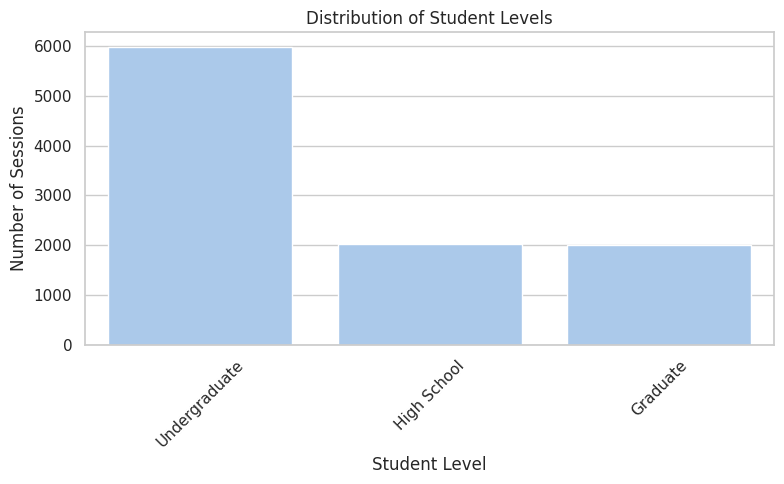

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
# Set Seaborn style
sns.set(style='whitegrid', palette='pastel')

# 1. Distribution of Student Levels
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='StudentLevel', order=df['StudentLevel'].value_counts().index)
plt.title('Distribution of Student Levels')
plt.xlabel('Student Level')
plt.ylabel('Number of Sessions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

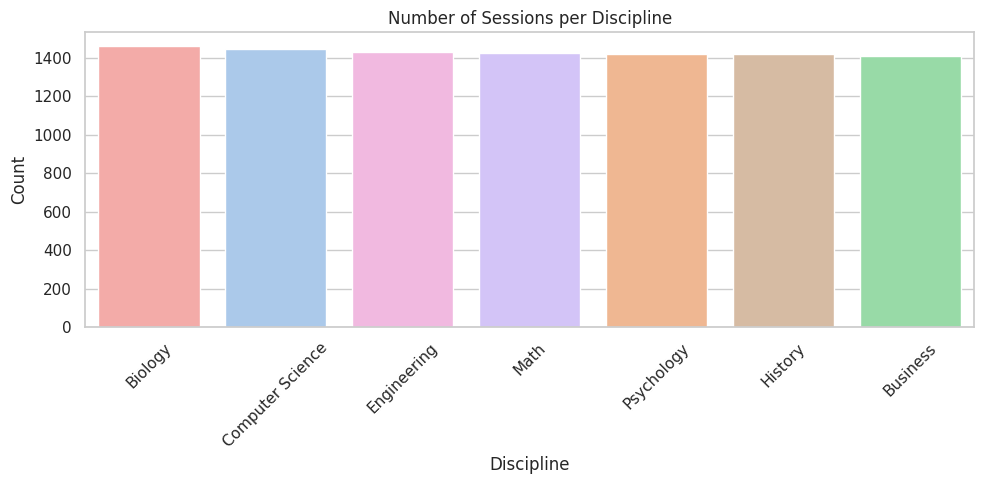

In [36]:
# 2. Sessions by Discipline
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Discipline', hue='Discipline', order=df['Discipline'].value_counts().index)
plt.title('Number of Sessions per Discipline')
plt.xlabel('Discipline')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

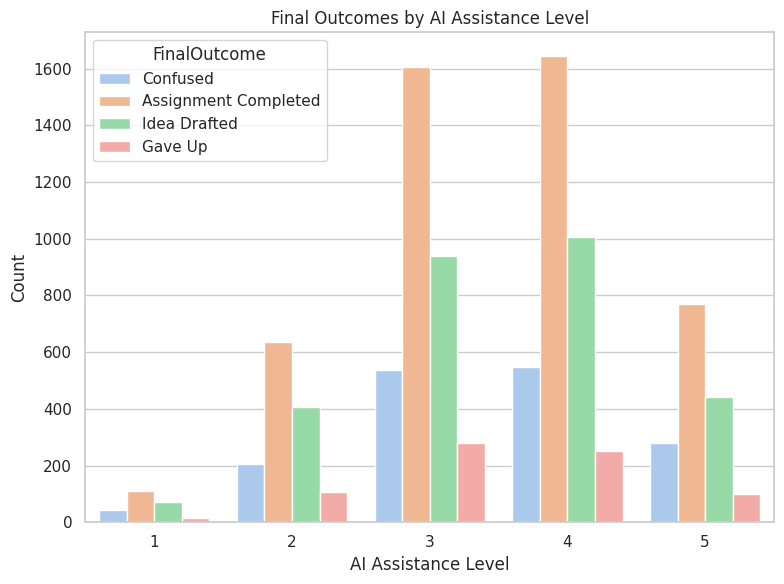

In [37]:
# 3. AI Assistance Level vs Final Outcome
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='AI_AssistanceLevel', hue='FinalOutcome')
plt.title('Final Outcomes by AI Assistance Level')
plt.xlabel('AI Assistance Level')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

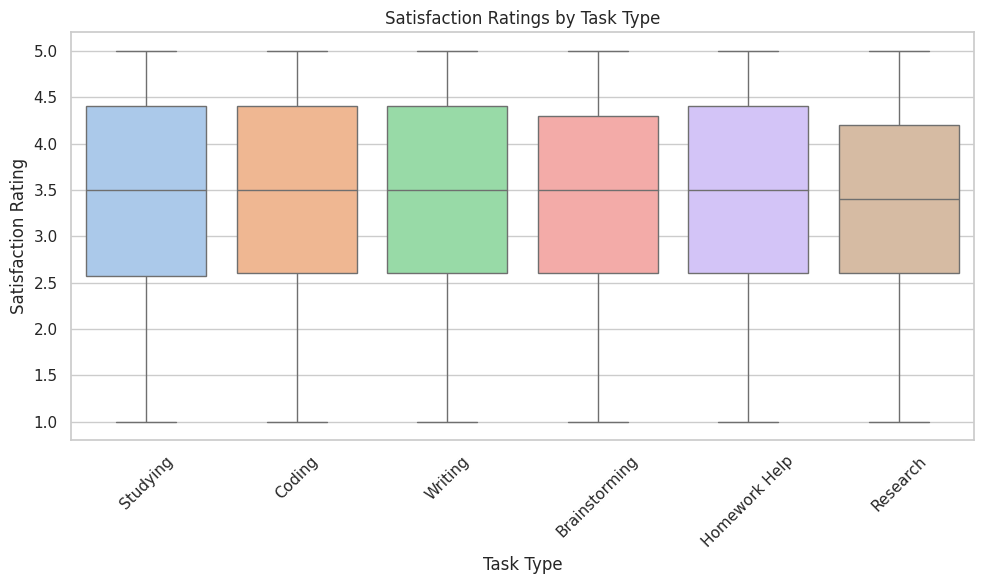

In [38]:
# 4. TaskType vs Satisfaction Rating
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='TaskType', y='SatisfactionRating', hue='TaskType')
plt.xlabel('Task Type')
plt.ylabel('Satisfaction Rating')
plt.title('Satisfaction Ratings by Task Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

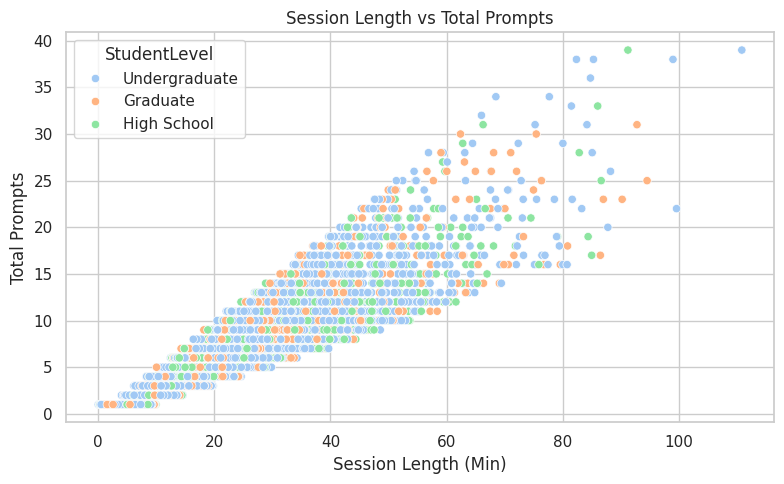

In [39]:
# 5. Session Length vs Total Prompts (Scatter)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='SessionLengthMin', y='TotalPrompts', hue='StudentLevel')
plt.title('Session Length vs Total Prompts')
plt.xlabel('Session Length (Min)')
plt.ylabel('Total Prompts')
plt.tight_layout()
plt.show()

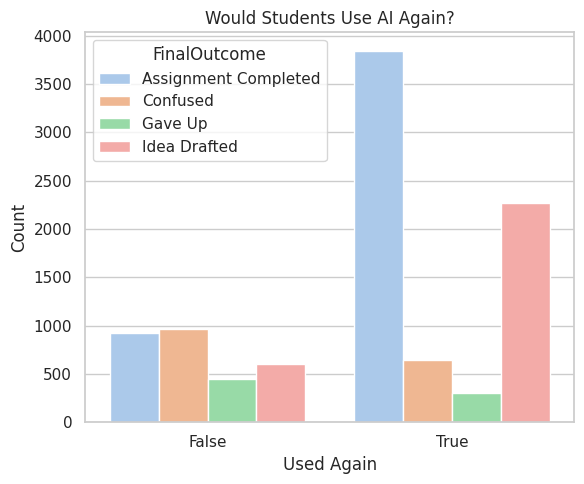

In [40]:
# 7. Usage Again Decision
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='UsedAgain', hue='FinalOutcome')
plt.title('Would Students Use AI Again?')
plt.xlabel('Used Again')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

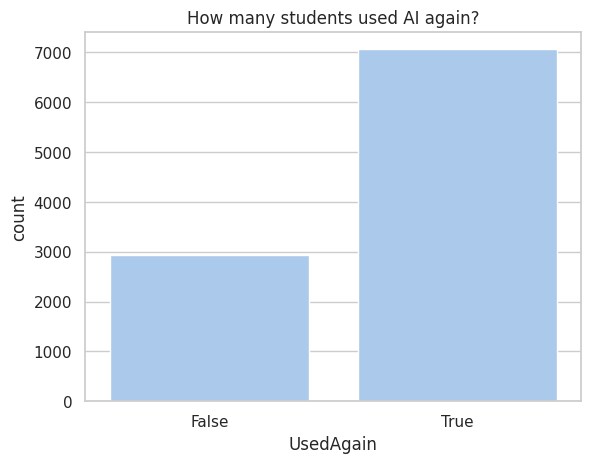

In [41]:
sns.countplot(x="UsedAgain", data=df)
plt.title("How many students used AI again?")
plt.show()

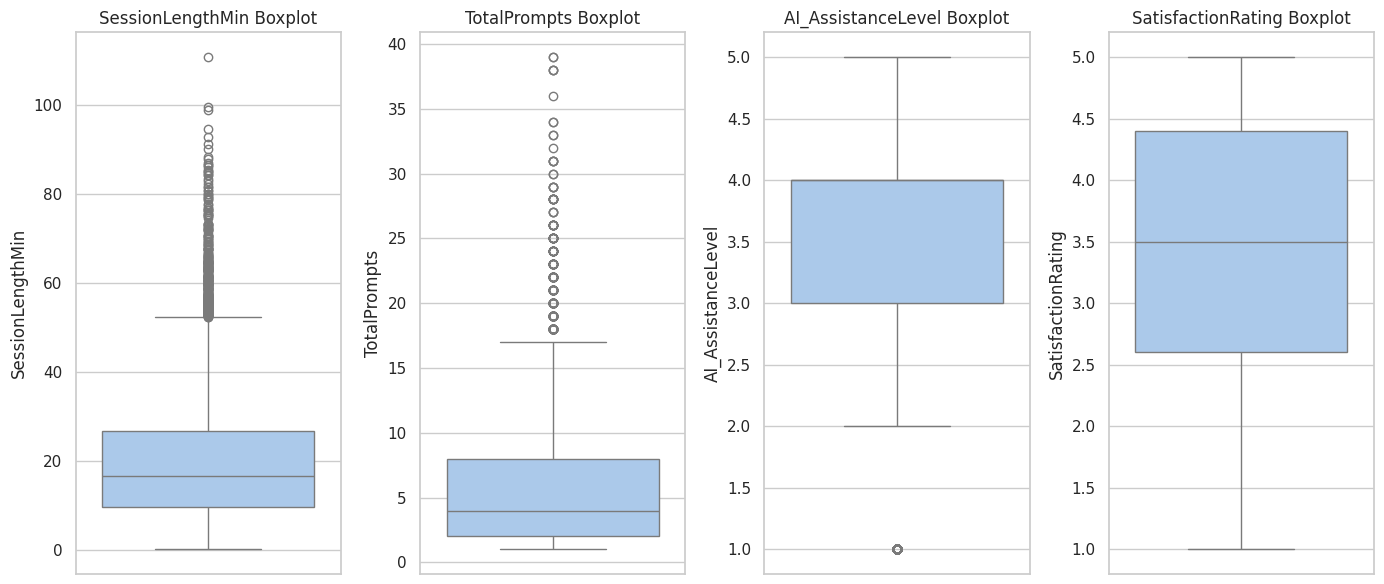

In [42]:
numeric_cols = ['SessionLengthMin', 'TotalPrompts', 'AI_AssistanceLevel', 'SatisfactionRating']

plt.figure(figsize=(14, 6))
for i, col in enumerate(numeric_cols):
    plt.subplot(1, len(numeric_cols), i+1)
    sns.boxplot(y=df[col])
    plt.title(f'{col} Boxplot')
plt.tight_layout()
plt.show()

In [43]:
def detect_outliers(column):
    q3=np.quantile(df[column],0.75)
    q1=np.quantile(df[column],0.25)

    iqr=q3-q1

    lower_limit = q1-(1.5*iqr)
    higher_limit = q3 +(1.5*iqr)

    before = df.shape[0]
    cleaned_data = df[(df[column] > lower_limit) & (df[column] < higher_limit)]
    after = cleaned_data.shape[0]

    print(f"Removed {before - after} outliers from '{column}'")
    return cleaned_data

columns=['SessionLengthMin', 'TotalPrompts', 'AI_AssistanceLevel', 'SatisfactionRating']
for column in columns:
    df=detect_outliers(column)

Removed 302 outliers from 'SessionLengthMin'
Removed 328 outliers from 'TotalPrompts'
Removed 231 outliers from 'AI_AssistanceLevel'
Removed 0 outliers from 'SatisfactionRating'


In [44]:
selected_cols = ['SessionLengthMin', 'TotalPrompts', 'AI_AssistanceLevel',
                 'SatisfactionRating', 'UsedAgain']

clean_corr = df[selected_cols].copy()

# Convert 'UsedAgain' to int if it's still boolean
clean_corr['UsedAgain'] = clean_corr['UsedAgain'].astype(int)

# Compute correlation
corr_matrix = clean_corr.corr()

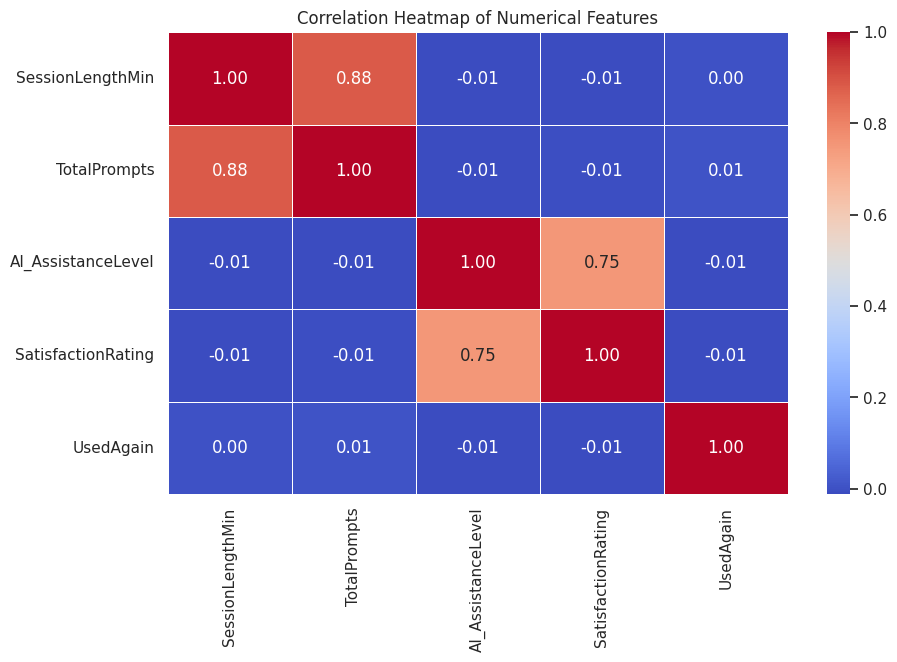

In [45]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

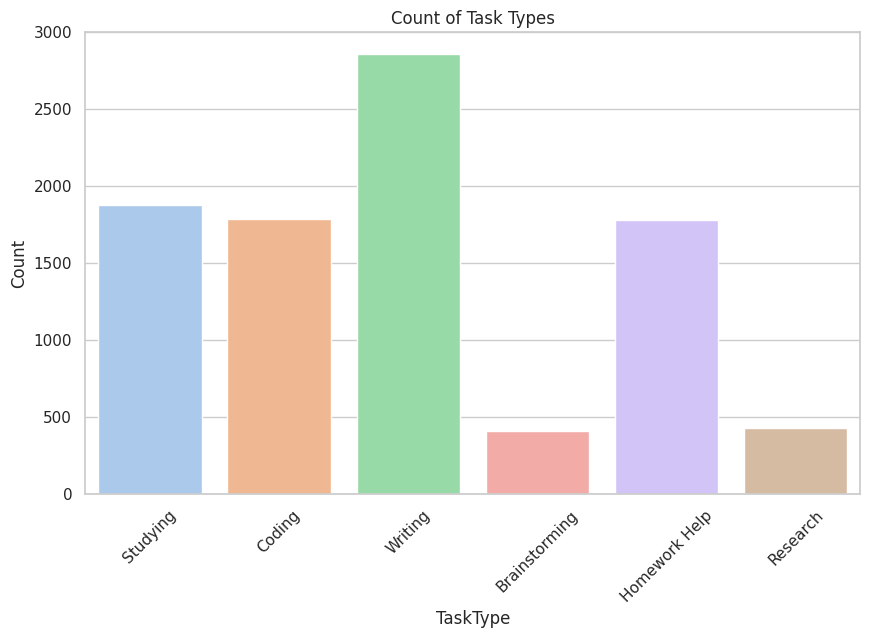

In [46]:
plt.figure(figsize=(10, 6))
sns.countplot(x='TaskType', hue='TaskType', data=df)
plt.xticks(rotation=45)
plt.title('Count of Task Types')
plt.xlabel('TaskType')
plt.ylabel('Count')
plt.show()

In [47]:
#PreProcessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Evaluation
from sklearn.metrics import accuracy_score,mean_squared_error,confusion_matrix,classification_report

In [48]:
le = LabelEncoder()

# Encode categorical variables
df['UsedAgain'] = df['UsedAgain'].astype(int)

for col in df.select_dtypes(include='object').columns:
    dummies = pd.get_dummies(df[col], prefix=col, drop_first=True).astype(int)
    df.drop(col, axis=1, inplace=True)
    df = pd.concat([df, dummies], axis=1)

In [49]:
# Split data

X = df.drop('UsedAgain', axis=1)
y = df['UsedAgain']
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

In [50]:
# Feature Scaling

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [51]:
# Train models

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
}
results = []
for name, model in models.items():
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  acc = accuracy_score(y_test, y_pred)
  mse = mean_squared_error(y_test, y_pred)
  cm = confusion_matrix(y_test, y_pred)
  cls_report = classification_report(y_test, y_pred)
  results.append((acc,
                  mse,
                  cm,
                  cls_report))

In [52]:
from tabulate import tabulate

# Create DataFrame with proper column names
results_df = pd.DataFrame(results, columns=[
    "Accuracy",
    "Error Rate (MSE)",
    "Confusion Matrix",
    "Classification Report"
])

# Add model names as a column
results_df.insert(0, "Model", list(models.keys()))

# Display formatted table using tabulate
print("\n📊 Model Performance Comparison:\n")
print(tabulate(results_df, headers="keys", tablefmt="grid", showindex=False))





📊 Model Performance Comparison:

+---------------------+------------+--------------------+--------------------+-------------------------------------------------------+
| Model               |   Accuracy |   Error Rate (MSE) | Confusion Matrix   | Classification Report                                 |
+=====================+============+====================+====================+=======================================================+
| Logistic Regression |   0.743435 |           0.256565 | [[ 243  294]       | precision    recall  f1-score   support               |
|                     |            |                    |  [ 175 1116]]      |                                                       |
|                     |            |                    |                    |            0       0.58      0.45      0.51       537 |
|                     |            |                    |                    |            1       0.79      0.86      0.83      1291 |
|                    

/tmp/ipython-input-1518860472.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="Accuracy", data=results_df, palette="coolwarm")


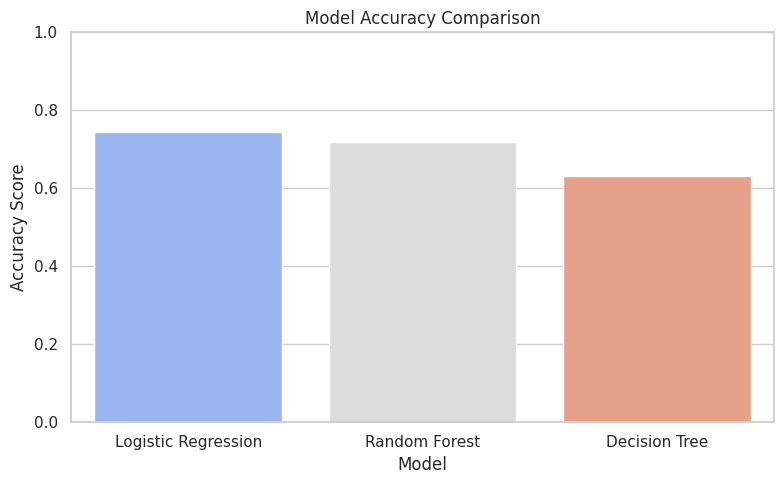

In [53]:
plt.figure(figsize=(8, 5))
sns.barplot(x="Model", y="Accuracy", data=results_df, palette="coolwarm")
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()